In [1]:
import pandas as pd
import numpy as np
import warnings


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('D:\\final project\\vehicles.csv')

In [4]:
df.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [5]:
df.shape


(426880, 26)

In [6]:
df.columns.tolist()

['id',
 'url',
 'region',
 'region_url',
 'price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'VIN',
 'drive',
 'size',
 'type',
 'paint_color',
 'image_url',
 'description',
 'county',
 'state',
 'lat',
 'long',
 'posting_date']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [8]:
null_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(null_percent.round(2))

county          100.00
size             71.77
cylinders        41.62
condition        40.79
VIN              37.73
drive            30.59
paint_color      30.50
type             21.75
manufacturer      4.13
title_status      1.93
lat               1.53
long              1.53
model             1.24
odometer          1.03
fuel              0.71
transmission      0.60
year              0.28
description       0.02
image_url         0.02
posting_date      0.02
url               0.00
price             0.00
state             0.00
region_url        0.00
region            0.00
id                0.00
dtype: float64


In [9]:
print(df['price'].describe())


count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64


In [10]:
null_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_percent.round(2)

county          100.00
size             71.77
cylinders        41.62
condition        40.79
VIN              37.73
drive            30.59
paint_color      30.50
type             21.75
manufacturer      4.13
title_status      1.93
lat               1.53
long              1.53
model             1.24
odometer          1.03
fuel              0.71
transmission      0.60
year              0.28
description       0.02
image_url         0.02
posting_date      0.02
url               0.00
price             0.00
state             0.00
region_url        0.00
region            0.00
id                0.00
dtype: float64

Text(0.5, 0, 'Price')

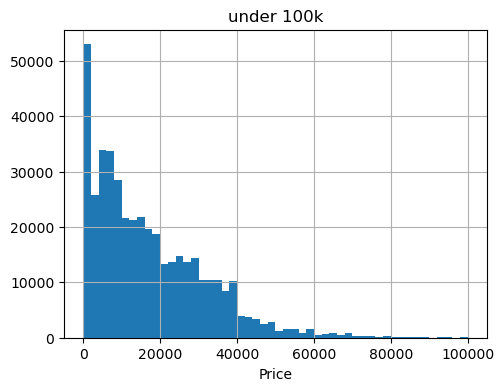

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df[df['price'] < 100000]['price'].hist(bins=50)
plt.title('under 100k')
plt.xlabel('Price')

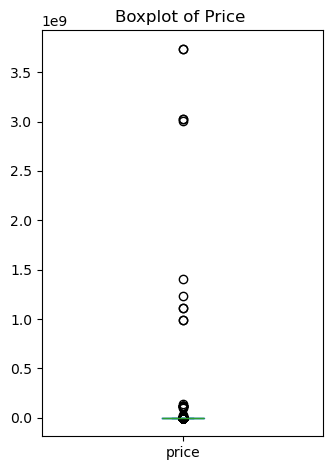

In [12]:
plt.subplot(1, 2, 2)
df['price'].plot(kind='box')
plt.title('Boxplot of Price ')
plt.tight_layout()
plt.show()

In [13]:
df = df[(df['price'] >= 500) & (df['price'] <= 100000)]

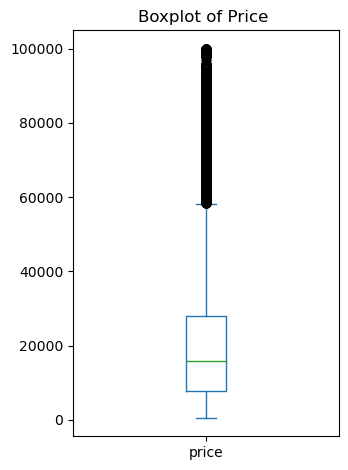

In [14]:
plt.subplot(1, 2, 2)
df['price'].plot(kind='box')
plt.title('Boxplot of Price ')
plt.tight_layout()
plt.show()

In [15]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower}")
print(f"Upper Bound: {upper}")



Q1: 7800.0
Q3: 27990.0
IQR: 20190.0
Lower Bound: -22485.0
Upper Bound: 58275.0


<Axes: >

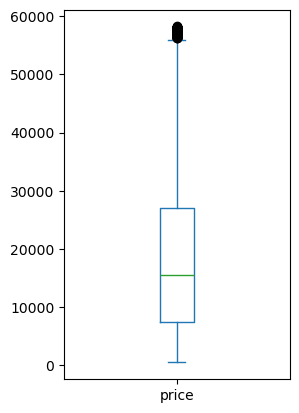

In [16]:
df = df[(df['price'] >= lower) & (df['price'] <= upper)]
plt.subplot(1, 2, 2)
df['price'].plot(kind='box')

In [17]:
df.shape

(377002, 26)

In [18]:
df.columns.tolist()

['id',
 'url',
 'region',
 'region_url',
 'price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel',
 'odometer',
 'title_status',
 'transmission',
 'VIN',
 'drive',
 'size',
 'type',
 'paint_color',
 'image_url',
 'description',
 'county',
 'state',
 'lat',
 'long',
 'posting_date']

In [19]:
drop = ['id', 'url', 'region_url', 'image_url', 
                'description', 'county', 'VIN', 
                'posting_date', 'lat', 'long']

In [20]:
df = df.drop(columns=drop)


In [21]:
df.isnull().sum().sort_values(ascending=False)/ len(df) * 100

size            71.632776
cylinders       40.698193
condition       37.308025
drive           30.630607
paint_color     28.994011
type            21.626676
manufacturer     3.927831
title_status     1.801317
model            1.124132
fuel             0.676124
odometer         0.542172
transmission     0.464984
year             0.262068
region           0.000000
price            0.000000
state            0.000000
dtype: float64

In [22]:
df.drop("size", axis=1, inplace=True)

In [23]:
cats = ['cylinders', 'condition', 'drive', 
                   'paint_color', 'type']
for col in cats:
    df[col] = df[col].fillna('unknown')

['manufacturer', 'title_status', 
                  'model', 'fuel', 'transmission']

In [24]:
from sklearn.impute import SimpleImputer
lowimputer = SimpleImputer(strategy='most_frequent')
df[['manufacturer']] = lowimputer.fit_transform(df[['manufacturer']])
df[['model']] = lowimputer.fit_transform(df[['model']])
df[['title_status']] = lowimputer.fit_transform(df[['title_status']])
df[['fuel']] = lowimputer.fit_transform(df[['fuel']])
df[['transmission']] = lowimputer.fit_transform(df[['transmission']])


year,odometer

In [25]:
numimputer = SimpleImputer(strategy='median')
df[['odometer']] = numimputer.fit_transform(df[['odometer']])
df[['year']] = numimputer.fit_transform(df[['year']])


In [26]:
df.isnull().sum()

region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
dtype: int64

In [27]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [28]:
numerical_features = ['year', 'odometer']

categorical_features = ['manufacturer', 'condition', 
                         'fuel', 'transmission', 
                         'drive', 'type', 'state']

In [29]:
from sklearn.model_selection import train_test_split
X = df.drop('price', axis=1)
y = df['price']

In [30]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
num_imputer = SimpleImputer(strategy='median')
x_train[numerical_features] = num_imputer.fit_transform(x_train[numerical_features])
x_test[numerical_features] = num_imputer.transform(x_test[numerical_features])

cat_imputer = SimpleImputer(strategy='most_frequent')
x_train[categorical_features] = cat_imputer.fit_transform(x_train[categorical_features])
x_test[categorical_features] = cat_imputer.transform(x_test[categorical_features])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
x_train_cat = encoder.fit_transform(x_train[categorical_features])
x_test_cat = encoder.transform(x_test[categorical_features])

scaler = StandardScaler()
x_train_num = scaler.fit_transform(x_train[numerical_features])
x_test_num = scaler.transform(x_test[numerical_features])

x_train_final = np.hstack([x_train_num, x_train_cat])
x_test_final = np.hstack([x_test_num, x_test_cat])

In [32]:
print(x_train_final.shape)
print(x_test_final.shape)

(301601, 128)
(75401, 128)


In [33]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    x_train_final, y_train,
    eval_set=[(x_test_final, y_test)],
    verbose=10
)

[0]	validation_0-rmse:11920.69663
[10]	validation_0-rmse:8059.01400
[20]	validation_0-rmse:7073.35483
[30]	validation_0-rmse:6720.41023
[40]	validation_0-rmse:6572.08449
[50]	validation_0-rmse:6473.85320
[60]	validation_0-rmse:6397.20560
[70]	validation_0-rmse:6337.43793
[80]	validation_0-rmse:6290.36297
[90]	validation_0-rmse:6249.77784
[99]	validation_0-rmse:6221.46364


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [34]:
y_pred = xgb_model.predict(x_test_final)

In [35]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(6221.4638148911545)

In [36]:
r2 = r2_score(y_test, y_pred)
r2

0.7596763372421265

In [37]:
xgb_model2 = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

In [38]:
xgb_model2.fit(
    x_train_final, y_train,
    eval_set=[(x_test_final, y_test)],
    verbose=50
)

[0]	validation_0-rmse:12444.79036
[50]	validation_0-rmse:6479.74059
[100]	validation_0-rmse:6053.58694
[150]	validation_0-rmse:5901.02851
[200]	validation_0-rmse:5805.77157
[250]	validation_0-rmse:5725.31999
[300]	validation_0-rmse:5663.59852
[350]	validation_0-rmse:5597.94082
[400]	validation_0-rmse:5541.90967
[450]	validation_0-rmse:5492.79036
[499]	validation_0-rmse:5446.58223


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [39]:
y_pred2 = xgb_model2.predict(x_test_final)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
r2_2 = r2_score(y_test, y_pred2)

print(f"RMSE: {rmse2:,.2f}")
print(f"R2:   {r2_2:.4f}")

RMSE: 5,446.58
R2:   0.8158


In [40]:
import subprocess
subprocess.run(['pip', 'install', 'lightgbm'])

CompletedProcess(args=['pip', 'install', 'lightgbm'], returncode=0)

In [41]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(
    x_train_final, y_train,
    eval_set=[(x_test_final, y_test)],
)


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,8
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [42]:
y_pred3 = lgb_model.predict(x_test_final)
rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
r2_3 = r2_score(y_test, y_pred3)

print(f"RMSE: {rmse3:,.2f}")
print(f"R2:   {r2_3:.4f}")

d:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


RMSE: 5,713.25
R2:   0.7973


In [45]:
import joblib

# حفظ الموديل
joblib.dump(xgb_model2, 'xgb_model.pkl')

# حفظ الـ Encoder
joblib.dump(encoder, 'encoder.pkl')

# حفظ الـ Scaler
joblib.dump(scaler, 'scaler.pkl')

# حفظ الـ Imputers
joblib.dump(num_imputer, 'num_imputer.pkl')
joblib.dump(cat_imputer, 'cat_imputer.pkl')

print("✅ كل حاجة اتحفظت!")

✅ كل حاجة اتحفظت!


In [46]:
# حفظ القيم الفريدة عشان نستخدمها في Streamlit
unique_values = {
    'manufacturer': sorted(df['manufacturer'].unique().tolist()),
    'condition': sorted(df['condition'].unique().tolist()),
    'fuel': sorted(df['fuel'].unique().tolist()),
    'transmission': sorted(df['transmission'].unique().tolist()),
    'drive': sorted(df['drive'].unique().tolist()),
    'type': sorted(df['type'].unique().tolist()),
    'state': sorted(df['state'].unique().tolist())
}

joblib.dump(unique_values, 'unique_values.pkl')

print("✅ القيم الفريدة اتحفظت!")
for col, vals in unique_values.items():
    print(f"{col}: {len(vals)} قيمة")

✅ القيم الفريدة اتحفظت!
manufacturer: 42 قيمة
condition: 7 قيمة
fuel: 5 قيمة
transmission: 3 قيمة
drive: 4 قيمة
type: 14 قيمة
state: 51 قيمة
